In [4]:
import pandas as pd

In [5]:
df = pd.read_csv("Student_Performance.csv")
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [6]:
from sklearn.preprocessing import LabelEncoder

In [7]:
le = LabelEncoder()
df["Extracurricular Activities"] = le.fit_transform(df["Extracurricular Activities"])

In [8]:
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0


In [9]:
X = df.iloc[:, 0:5]
y = df.iloc[:, 5]

In [10]:
X.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced
0,7,99,1,9,1
1,4,82,0,4,2
2,8,51,1,7,2
3,5,52,1,5,2
4,7,75,0,8,5


In [11]:
y.head()

0    91.0
1    65.0
2    45.0
3    36.0
4    66.0
Name: Performance Index, dtype: float64

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
X_train , X_test , y_train , y_test  =  train_test_split(X,y , test_size = 0.2)

In [14]:
from sklearn.linear_model import LinearRegression

In [15]:
model = LinearRegression()

In [16]:
model.fit(X_train, y_train)

LinearRegression()

In [17]:
"Coefficients (m1, m2, m3, m4, m5):", model.coef_

('Coefficients (m1, m2, m3, m4, m5):',
 array([2.85476503, 1.01889422, 0.6141362 , 0.48883437, 0.19858677]))

In [18]:
"Intercept (c):", model.intercept_

('Intercept (c):', np.float64(-34.18238810064325))

In [19]:
y_pred = model.predict(X_test)

In [20]:
import matplotlib.pyplot as plt

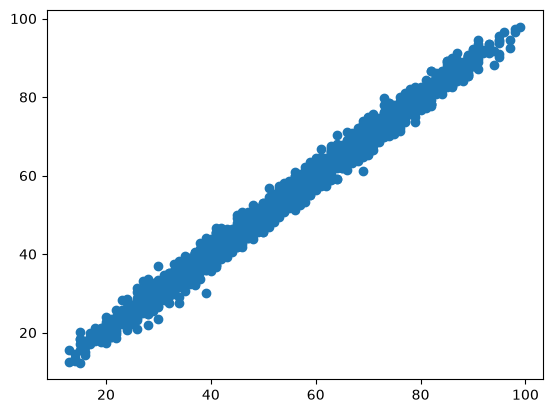

In [21]:
plt.scatter(y_test, y_pred)

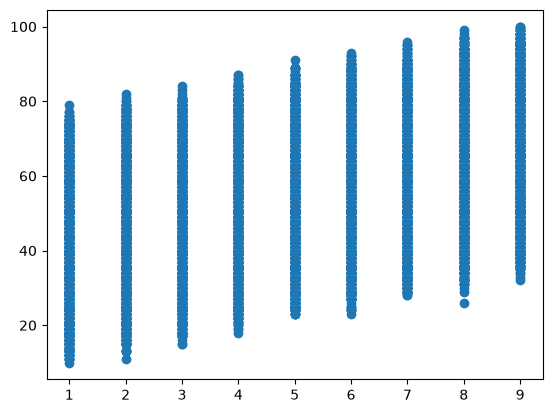

In [22]:
plt.scatter(df['Hours Studied'], df['Performance Index'],label='Data')

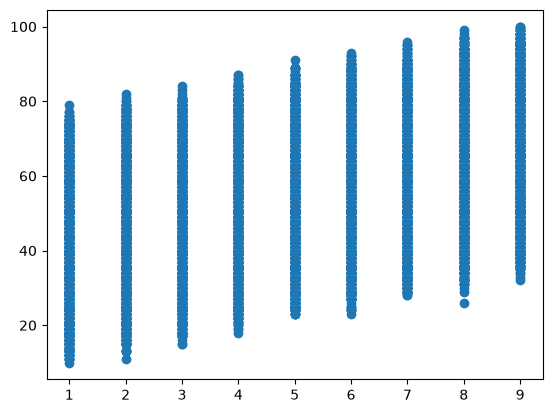

In [28]:
plt.scatter(df['Hours Studied'], df['Performance Index'])

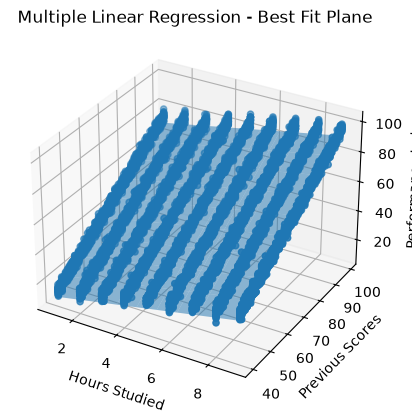

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(df["Hours Studied"], df["Previous Scores"], df["Performance Index"])

x_range = np.linspace(df["Hours Studied"].min(), df["Hours Studied"].max(), 10)
y_range = np.linspace(df["Previous Scores"].min(), df["Previous Scores"].max(), 10)
x_surf, y_surf = np.meshgrid(x_range, y_range)
z_surf = model.intercept_ + model.coef_[0]*x_surf + model.coef_[1]*y_surf
ax.plot_surface(x_surf, y_surf, z_surf, alpha=0.5)

ax.set_xlabel("Hours Studied")
ax.set_ylabel("Previous Scores")
ax.set_zlabel("Performance Index")
plt.title("Multiple Linear Regression - Best Fit Plane")
plt.show()